# 00｜一键体验：让 Attention 找到第 0 位颜色 🔎

先不推导公式。运行后观察一串颜色、模型的回答，以及末尾 QUERY 把注意力分给了哪些位置。

**操作：**选择课程 Python 内核并点击 `Run All`。

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import torch

LAB_DIR = Path.cwd()
if not (LAB_DIR / "transformer_lab").is_dir():
    LAB_DIR = (LAB_DIR / "04_transformer_lab").resolve()
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

# 共享服务器约定：一个 Notebook 只占一个 CPU 线程。
torch.set_num_threads(1)

from transformer_lab import challenge_report, predict_proba, quick_demo


## 游戏规则

每条序列包含 12 个颜色 token，红、绿、蓝各出现 4 次，末尾再放一个 `QUERY`。

~~~text
第 0 位的颜色 → 其他颜色 → …… → QUERY：第 0 位是什么？
~~~

三种颜色总数相同，所以模型不能靠计数作弊。随机猜测 Accuracy 大约是 33.3%。

**运行前先猜：**QUERY 的 Attention 会不会集中到第 0 位？

实验                          测试Acc       参数量     更新        组合预算       秒
有位置编码                       99.7%     8,771    228   2,433,600    0.98


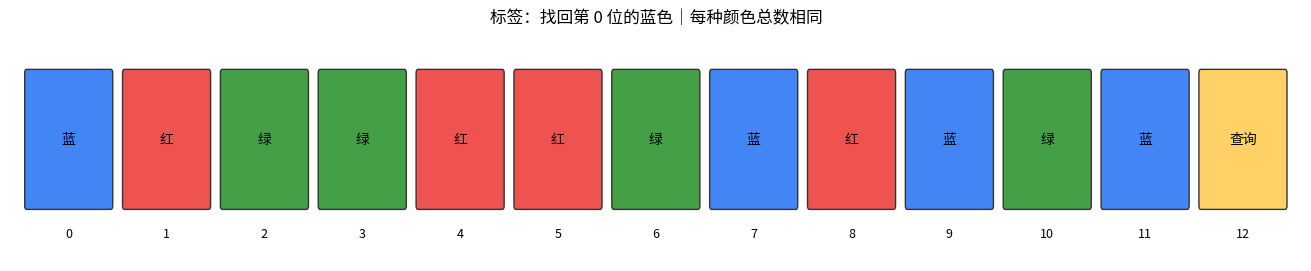

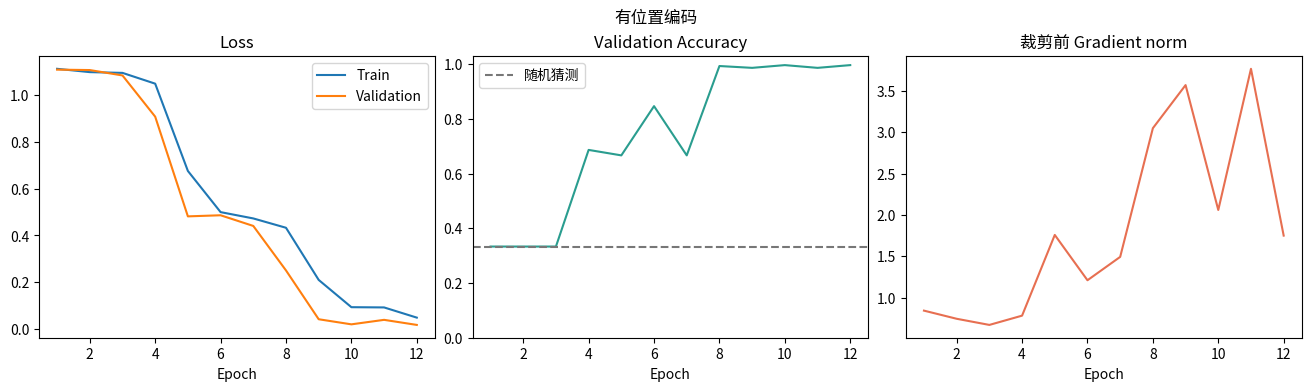

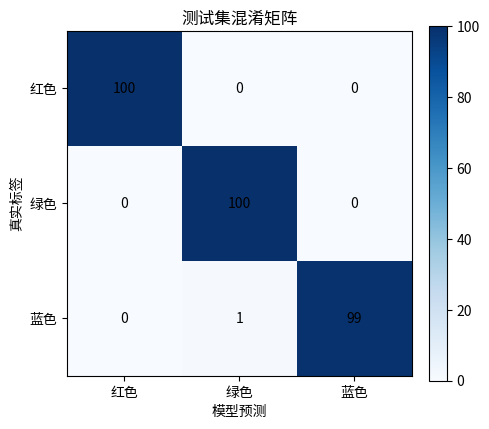

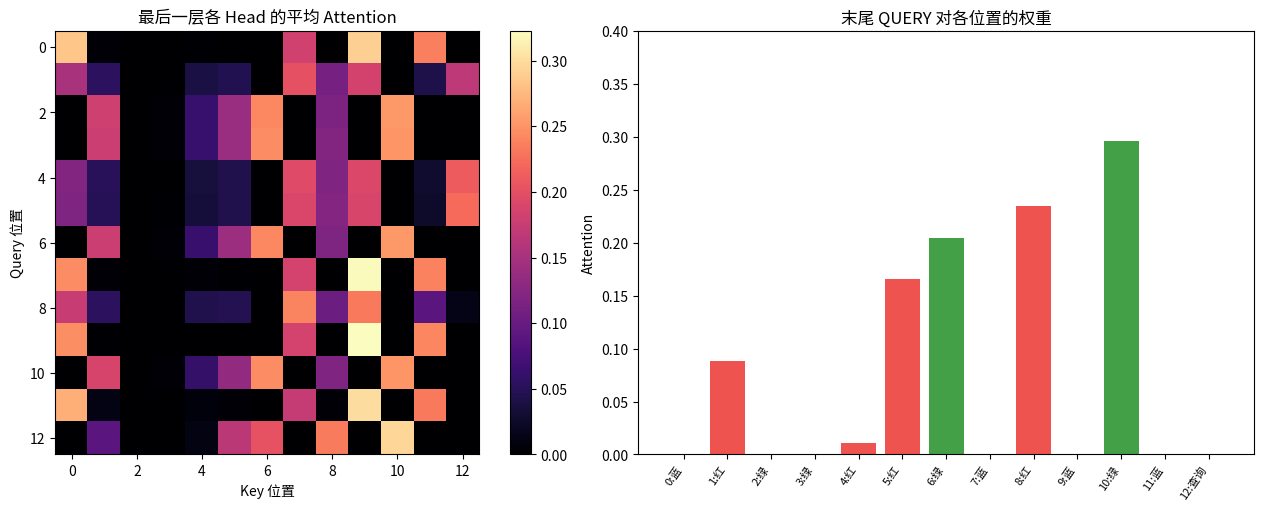

In [2]:
DEVICE = "cpu"
# 获得教师分配后才可改成 "cuda:x"，x 是指定 GPU 编号；不要使用 auto。

result = quick_demo(
    content_length=12,
    d_model=32,
    num_heads=4,
    num_layers=1,
    epochs=12,
    seed=42,
    device=DEVICE,
)


## 看一次具体回答

概率最大的颜色是模型的回答。徽章只用于增加趣味；没有集齐也可以完成实验，但必须留下证据和下一步。

In [3]:
test_x, test_y = next(iter(result["loaders"]["test"]))
probabilities = predict_proba(result["model"], test_x[:1], device=DEVICE)[0]
names = result["data"].class_names

print("第 0 位真实颜色：", names[int(test_y[0])])
print("模型回答：", names[int(probabilities.argmax())])
print("红/绿/蓝概率：", probabilities.numpy().round(3).tolist())

score = challenge_report(result)
print(f"本轮获得 {score['badge_count']}/4 枚徽章。")


第 0 位真实颜色： 蓝色
模型回答： 蓝色
红/绿/蓝概率： [0.003000000026077032, 0.0010000000474974513, 0.9959999918937683]

四徽章报告（不使用运行时间计分）
测试 Accuracy：99.7%｜目标 85.0%
长度 24 迁移：92.7%｜目标 45.0%
参数量：8,771｜预算 15,000
Attention 组合预算：2,433,600｜预算 3,000,000
徽章： ✅寻宝 ✅远行 ✅轻装 ✅节能
本轮获得 4/4 枚徽章。


## 看图顺序

1. 三种颜色是否都出现相同次数？
2. Loss 是否总体下降，验证 Accuracy 是否超过随机猜测？
3. 混淆矩阵是否主要集中在对角线？
4. QUERY 的 Attention 是否在第 0 位较高？

Attention 图描述当前模型的权重分配，不是“模型思维”或完整因果解释。结果只适用于当前数据、seed 和预算。

## 完成本页后：释放资源并结束内核

先保存 Notebook，再运行最后一格。运行后 VS Code 显示内核停止属于正常现象。

In [ ]:
%reset -f
import gc
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython

plt.close("all")
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("清理完成，正在结束当前 Notebook 的 Python 内核……")
get_ipython().kernel.do_shutdown(restart=False)
